<table>
<tr>                                                                                   
     <th>
         <div style='padding:15px;color:#030aa7;font-size:240%;text-align: center;font-style: italic;font-weight: bold;font-family: Georgia, serif'><a href="https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset">Maladie Cardiovasculaire</a></div>
     </th>
     <th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/maladie_cardiovasculaire_logo.jpg" width="96"></th>
 </tr>
</table>

<div style='text-align: center'>
<img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/maladie_cardiovasculaire.jpg" width="512">
</div>

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Introduction</div></b>
## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Import libriries </div></b>

In [1]:
import pandas as pd, numpy as np, seaborn as sns, warnings, os, sys, time, copy as cp
from datetime import datetime as dt
from matplotlib import pyplot as plt

import matplotlib.font_manager as fm
import plotly.express as px
import plotly.graph_objs as go

In [2]:
from sklearn.model_selection import train_test_split

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Outils du document</div></b>

In [3]:
sys.path.append(os.path.abspath('../outils/'))
from prjFormation import palette

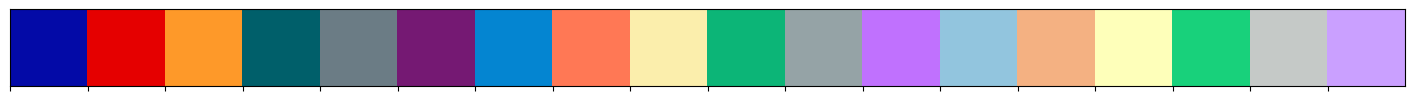

In [4]:
# palette = [ "#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973", 
#             "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe", 
#             "#d1e5f0", "#fddbc7", "#ffffcb", "#12e193", "#d8dcd6", "#dfc5fe", 
#           ]
sns.palplot(sns.color_palette(palette[:18]))

In [5]:
from classificationBinaires import initDictionnaireClassificateurs, executionEssaiComparaisonClassificateurs,\
                                   affichageEvolutionMetriques, affichageROC, executeValidationCroisee, afficheSeparationsBinaires

In [6]:
from prjFormation import initProjet,affichageDonnees2d,affichageDonnees3d,createLinkageMatrix, afficheDendrogram,\
                         affichageDistribution,afficheColonneCible, add_median_labels, formatPct, createColumnsQualitatives

In [7]:
font1 = fm.FontProperties(size=20)
font2 = fm.FontProperties(size=24)

warnings.filterwarnings(action="ignore")

if int(str(sns.__version__).split('.')[1]) > 8 : 
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')
sns.set(font_scale=2)

In [8]:
projet = initProjet(repertoireRacine='.',nomProjet='Maladie Cardiovasculaire')

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Démarche pour constituer un modèle de classification </div></b>

<img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/classification/demarche.png" width="800">

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Lecture des données</div></b>

<table>
       <tr>                                                                                   
             <th  style="text-align:left;background-color:#053061;color:white;"> </th>
             <th  style="text-align:left;background-color:#053061;color:white;">Colonne initiale </th>
             <th  style="text-align:left;background-color:#053061;color:white;">Description</th>
        </tr> 
        <tr>
            <th  style="text-align:left">0</th><th  style="text-align:left;font-style: italic">AGE                </th>
            <th  style="text-align:left;font-style: italic">Âge int (jours)</th>
        </tr> 
        <tr>
            <th  style="text-align:left">1</th><th  style="text-align:left;font-style: italic">GENDER             </th>
            <th  style="text-align:left;font-style: italic">Taille int (cm)</th>
        </tr>
        <tr>
            <th  style="text-align:left">2</th><th  style="text-align:left;font-style: italic">HEIGHT             </th>
            <th  style="text-align:left;font-style: italic">Poids float (kg)</th>
        </tr>
        <tr>
            <th  style="text-align:left">3</th><th  style="text-align:left;font-style: italic">WEIGHT             </th>
            <th  style="text-align:left;font-style: italic">Sexe </th>
        </tr>
        <tr>
            <th  style="text-align:left">4</th><th  style="text-align:left;font-style: italic">AP_HIGH            </th>
            <th  style="text-align:left;font-style: italic">Pression artérielle systolique int</th>
        </tr>
        <tr>
            <th  style="text-align:left">5</th><th  style="text-align:left;font-style: italic">AP_LOW             </th>
            <th  style="text-align:left;font-style: italic">Pression artérielle diastolique int</th>
        </tr>
        <tr>
            <th  style="text-align:left">6</th><th  style="text-align:left;font-style: italic">CHOLESTEROL        </th>
            <th  style="text-align:left;font-style: italic">Cholestérol <br>1 : normal, <br>2 : supérieur à la normale, <br>3 : bien upérieur à la normale</th>
        </tr>
        <tr>
            <th  style="text-align:left">7</th><th  style="text-align:left;font-style: italic">GLUCOSE            </th>
            <th  style="text-align:left;font-style: italic">Glucose <br>1 : normal, <br>2 : supérieur à la normale, <br>3 : bien supérieur à a normale</th>
        </tr>
        <tr>
            <th  style="text-align:left">8</th><th  style="text-align:left;font-style: italic">SMOKE              </th>
            <th  style="text-align:left;font-style: italic">Tabagisme binaire</th>
        </tr>
        <tr>
            <th  style="text-align:left">9</th><th  style="text-align:left;font-style: italic">ALCOHOL            </th>
            <th  style="text-align:left;font-style: italic">Consommation d'alcool binaire</th>
        </tr>
        <tr>
            <th  style="text-align:left">10</th><th  style="text-align:left;font-style: italic">PHYSICAL_ACTIVITY </th>
            <th  style="text-align:left;font-style: italic">Activité physique binaire</th>
        </tr>
        <tr>
            <th  style="text-align:left">11</th><th  style="text-align:left;color:red;font-style: italic">CARDIO_DISEASE    </th>
            <th  style="text-align:left;color:red;font-style: italic">Présence ou absence de maladie cardiovasculaire binaire</th>
        </tr>
</table>

In [9]:
donnees = pd.read_csv('../donnees/Cardiovascular Disease/cardiovascular_diseases_dv3.csv', 
                      sep=';').reset_index().set_index(['index','CARDIO_DISEASE'])
cible = 'CARDIO_DISEASE'

In [10]:
donnees.shape

(68783, 11)

In [11]:
donnees.sample(5)

,,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY
index,CARDIO_DISEASE,,,,,,,,,,,
36626,0,50,2,184,95,120,80,1,1,0,0,1
26428,0,54,2,165,60,120,80,1,1,0,0,1
42052,1,58,1,174,78,130,80,1,1,0,0,1
4693,1,58,1,151,45,140,90,3,1,0,0,1
48145,1,50,1,164,85,140,90,3,1,0,0,1


In [12]:
donnees = donnees[::10]

In [13]:
donnees.shape

(6879, 11)

In [35]:
donnees.isna().sum().sum()

0

>> <div style='padding:15px;color:#030aa7;background-color:#d8dcd6;font-size:120%;text-align: left;font-family: Georgia, serif'>Il n'y a pas de valeurs non renseignées</div>

<img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/classification/echantillonInitial.png" width="800">

In [14]:
X = donnees.copy()
y = X.reset_index()[cible]
y.index = X.index

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Separation des données pour l'apprentissage</div></b>

<img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/classification/echantillonTraitementValidation.png" width="800">

In [15]:
X_traitement, X_validation, y_traitement, y_validation = train_test_split( X, 
                                                                           y, 
                                                                           test_size=1024, 
                                                                           random_state=0, 
                                                                           stratify = y
                                                                           ) 
donnees.loc[X_validation.index ,'échantillon'] = 'validation'

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Separation des données pour l'apprentissage</div></b>

<img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/classification/echantillonApprentissageTest.png" width="800">

In [16]:
X_train, X_test, y_train, y_test = train_test_split( X_traitement, 
                                                     y_traitement, 
                                                     test_size=1024, 
                                                     random_state=0, 
                                                     stratify = y_traitement
                                                   ) 
donnees.loc[X_train.index,'échantillon'] = 'apprentissage'
donnees.loc[X_test.index ,'échantillon'] = 'test'

In [17]:
donnees.reset_index(inplace=True)
donnees.set_index(['échantillon','index',cible],inplace=True)
# donnees.to_parquet(os.path.join(projet.repertoireDonnees,'donnees_echantillons.parquet'))

In [18]:
X = donnees.copy()
y = X.reset_index()[cible]
y.index = X.index

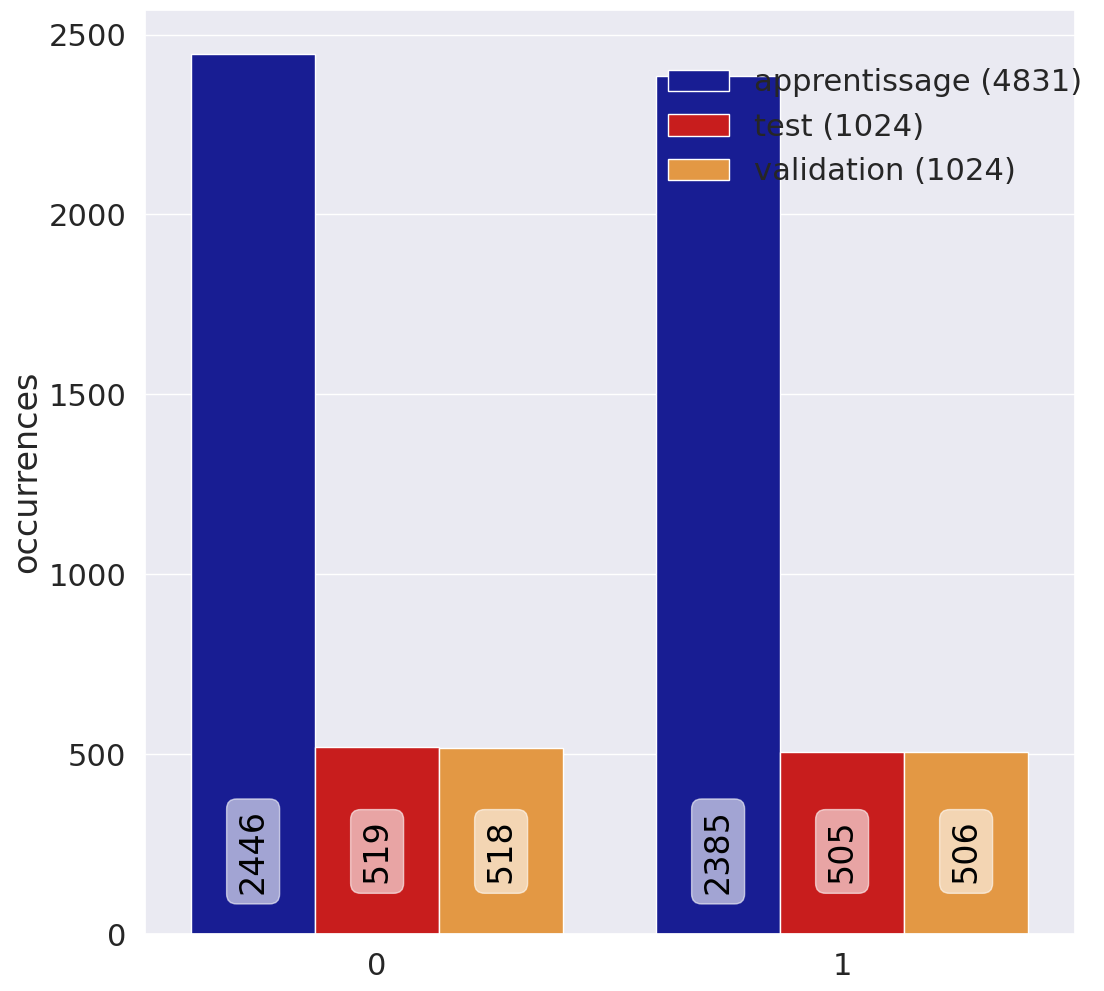

In [19]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(12,12))
afficheSeparationsBinaires(donnees, palette, ax, cible=cible)

In [20]:
X_train, X_test, y_train, y_test = X.loc[('apprentissage'),:],\
                                   X.loc[('test'),:],\
                                   y.loc[('apprentissage')],\
                                   y.loc[('test')] 

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Déclaration des classificateurs </div></b>

In [21]:
classificateursDict =  initDictionnaireClassificateurs(arbres=512)

# classificateursDict.pop('AdaBoost')
# classificateursDict.pop('Gaussian_Process')
# classificateursDict.pop('GaussianNaiveBayes')
classificateursDict.pop('LightGBM')
# classificateursDict.pop('Linear_SVM')
# classificateursDict.pop('LogisticRegression')
# classificateursDict.pop('Nearest_Neighbors')
# classificateursDict.pop('Neural_Net')
# classificateursDict.pop('Poly_NuSVM')
# classificateursDict.pop('QuadraticDiscriminant')
# classificateursDict.pop('Radial_NuSVM')
# classificateursDict.pop('Random_Forest')
# classificateursDict.pop('Stochastic_GD')
# classificateursDict.pop('XGBoost')

,boosting_type,'gbdt'
,num_leaves,20
,max_depth,-1
,learning_rate,0.1
,n_estimators,512
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.01
,min_child_weight,0.001
,min_child_samples,10


In [22]:
classificateursDict

{'Random_Forest': RandomForestClassifier(max_depth=6, max_features=3, min_samples_split=4,
                        n_estimators=512, n_jobs=-1),
 'AdaBoost': AdaBoostClassifier(n_estimators=512),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='auc', feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=512,
               n_jobs=None, num_parallel_tree=None, ...),
 'LogisticRegression': 

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Essai initial avec les donnes sans aucun traitement</div></b> 

AdaBoost               0.7129	--	Area under the ROC curve : 0.7717	--	Exécution  :.67s
GaussianNaiveBayes     0.6914	--	Area under the ROC curve : 0.7557	--	Exécution  :.01s
Gaussian_Process       0.6338	--	Area under the ROC curve : 0.6391	--	Exécution  :16.61s
Linear_SVM             0.7061	--	Area under the ROC curve : 0.7697	--	Exécution  :130.55s
LogisticRegression     0.7197	--	Area under the ROC curve : 0.7730	--	Exécution  :.82s
Nearest_Neighbors      0.6934	--	Area under the ROC curve : 0.7555	--	Exécution  :.10s
Neural_Net             0.6973	--	Area under the ROC curve : 0.7554	--	Exécution  :.22s
Poly_NuSVM             0.6924	--	Area under the ROC curve : 0.7634	--	Exécution  :.47s
QuadraticDiscriminant  0.6621	--	Area under the ROC curve : 0.7356	--	Exécution  :.01s
Radial_NuSVM           0.5898	--	Area under the ROC curve : 0.6408	--	Exécution  :3.47s
Random_Forest          0.7256	--	Area under the ROC curve : 0.7804	--	Exécution  :.49s
Stochastic_GD          0.5420	--	Area

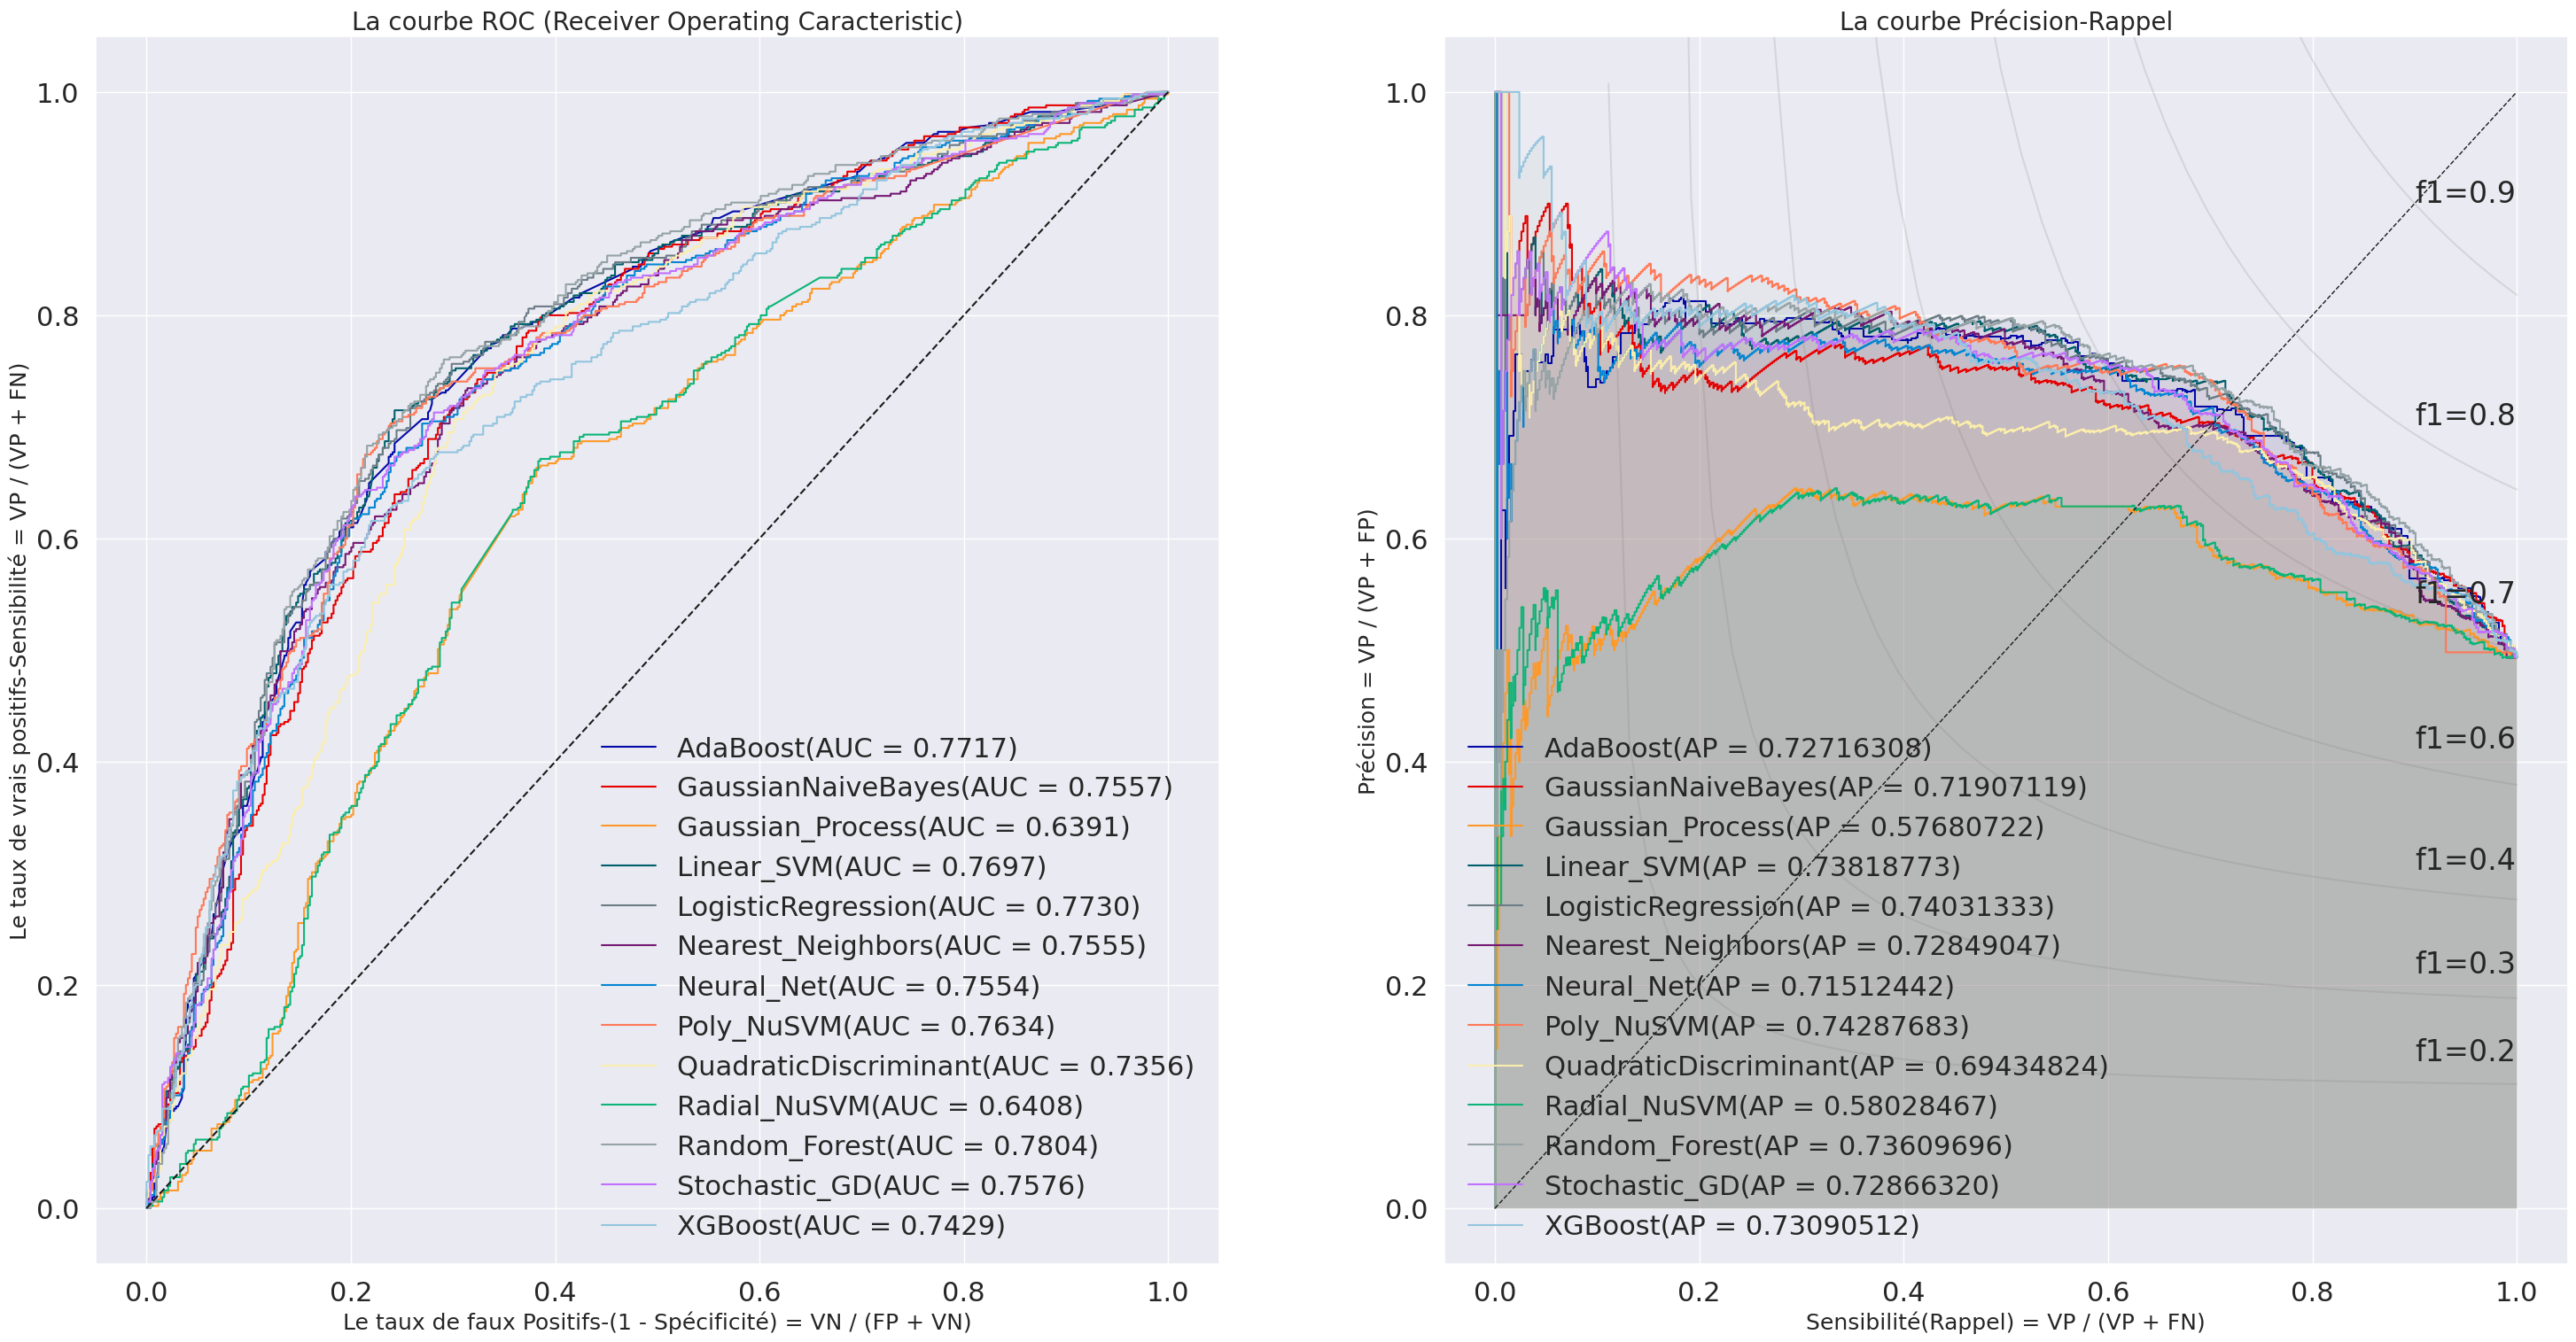

Exécution  :155.05s


In [23]:
resultats = executionEssaiComparaisonClassificateurs(classificateursDict, 
                                                     X_train, 
                                                     y_train,
                                                     X_test, 
                                                     y_test, 
                                                     couleurs = palette,
                                                     nom_essai = 'Initial', 
                                                     projet=projet)

In [24]:
resultats.drop(columns=['vrais_positifs', 'vrais_negatifs',
                         'faux_positifs', 'faux_negatifs']).sort_values('accuracy',ascending=False).head(16)

,aucROC,avgPrecRec,accuracy,f1,precision,sensibilite,specificite,logloss,hammingloss,jaccard,essai
Classifieur,,,,,,,,,,,
Random_Forest,0.780364,0.736097,0.725586,0.703273,0.753394,0.659406,0.789981,9.890885,0.274414,0.542345,Initial
LogisticRegression,0.773008,0.740313,0.719727,0.698212,0.744395,0.657426,0.780347,10.102079,0.280273,0.536349,Initial
AdaBoost,0.771657,0.727163,0.712891,0.687234,0.742529,0.639604,0.784200,10.348471,0.287109,0.523501,Initial
Linear_SVM,0.769723,0.738188,0.706055,0.668867,0.752475,0.601980,0.807322,10.594863,0.293945,0.502479,Initial
Neural_Net,0.755407,0.715124,0.697266,0.709738,0.673179,0.750495,0.645472,10.911653,0.302734,0.550073,Initial
XGBoost,0.742885,0.730905,0.697266,0.686235,0.701863,0.671287,0.722543,10.911653,0.302734,0.522342,Initial
Nearest_Neighbors,0.755497,0.728490,0.693359,0.675620,0.706263,0.647525,0.737958,11.052448,0.306641,0.510140,Initial
Poly_NuSVM,0.763368,0.742877,0.692383,0.642452,0.752660,0.560396,0.820809,11.087647,0.307617,0.473244,Initial
GaussianNaiveBayes,0.755659,0.719071,0.691406,0.652747,0.733333,0.588119,0.791908,11.122846,0.308594,0.484502,Initial


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Données centrées et réduites (StandardScaler)</div></b> 

In [25]:
qualitatives = ['AGE', 'HEIGHT', 'WEIGHT', 'AP_HIGH', 'AP_LOW']

In [26]:
from sklearn.preprocessing import StandardScaler
modelStd = StandardScaler()
modelStd.fit(X_train[qualitatives])
X_train[qualitatives] = modelStd.transform(X_train[qualitatives])
X_test[qualitatives] = modelStd.transform(X_test[qualitatives])

AdaBoost               0.7129	--	Area under the ROC curve : 0.7717	--	Exécution  :.67s
GaussianNaiveBayes     0.6914	--	Area under the ROC curve : 0.7557	--	Exécution  :.01s
Gaussian_Process       0.7295	--	Area under the ROC curve : 0.7691	--	Exécution  :4.79s
Linear_SVM             0.7051	--	Area under the ROC curve : 0.7698	--	Exécution  :3.35s
LogisticRegression     0.7197	--	Area under the ROC curve : 0.7730	--	Exécution  :.46s
Nearest_Neighbors      0.7188	--	Area under the ROC curve : 0.7640	--	Exécution  :.13s
Neural_Net             0.7256	--	Area under the ROC curve : 0.7760	--	Exécution  :.36s
Poly_NuSVM             0.4102	--	Area under the ROC curve : 0.6444	--	Exécution  :3.77s
QuadraticDiscriminant  0.6621	--	Area under the ROC curve : 0.7356	--	Exécution  :.01s
Radial_NuSVM           0.6543	--	Area under the ROC curve : 0.6861	--	Exécution  :4.02s
Random_Forest          0.7285	--	Area under the ROC curve : 0.7807	--	Exécution  :.50s
Stochastic_GD          0.7168	--	Area u

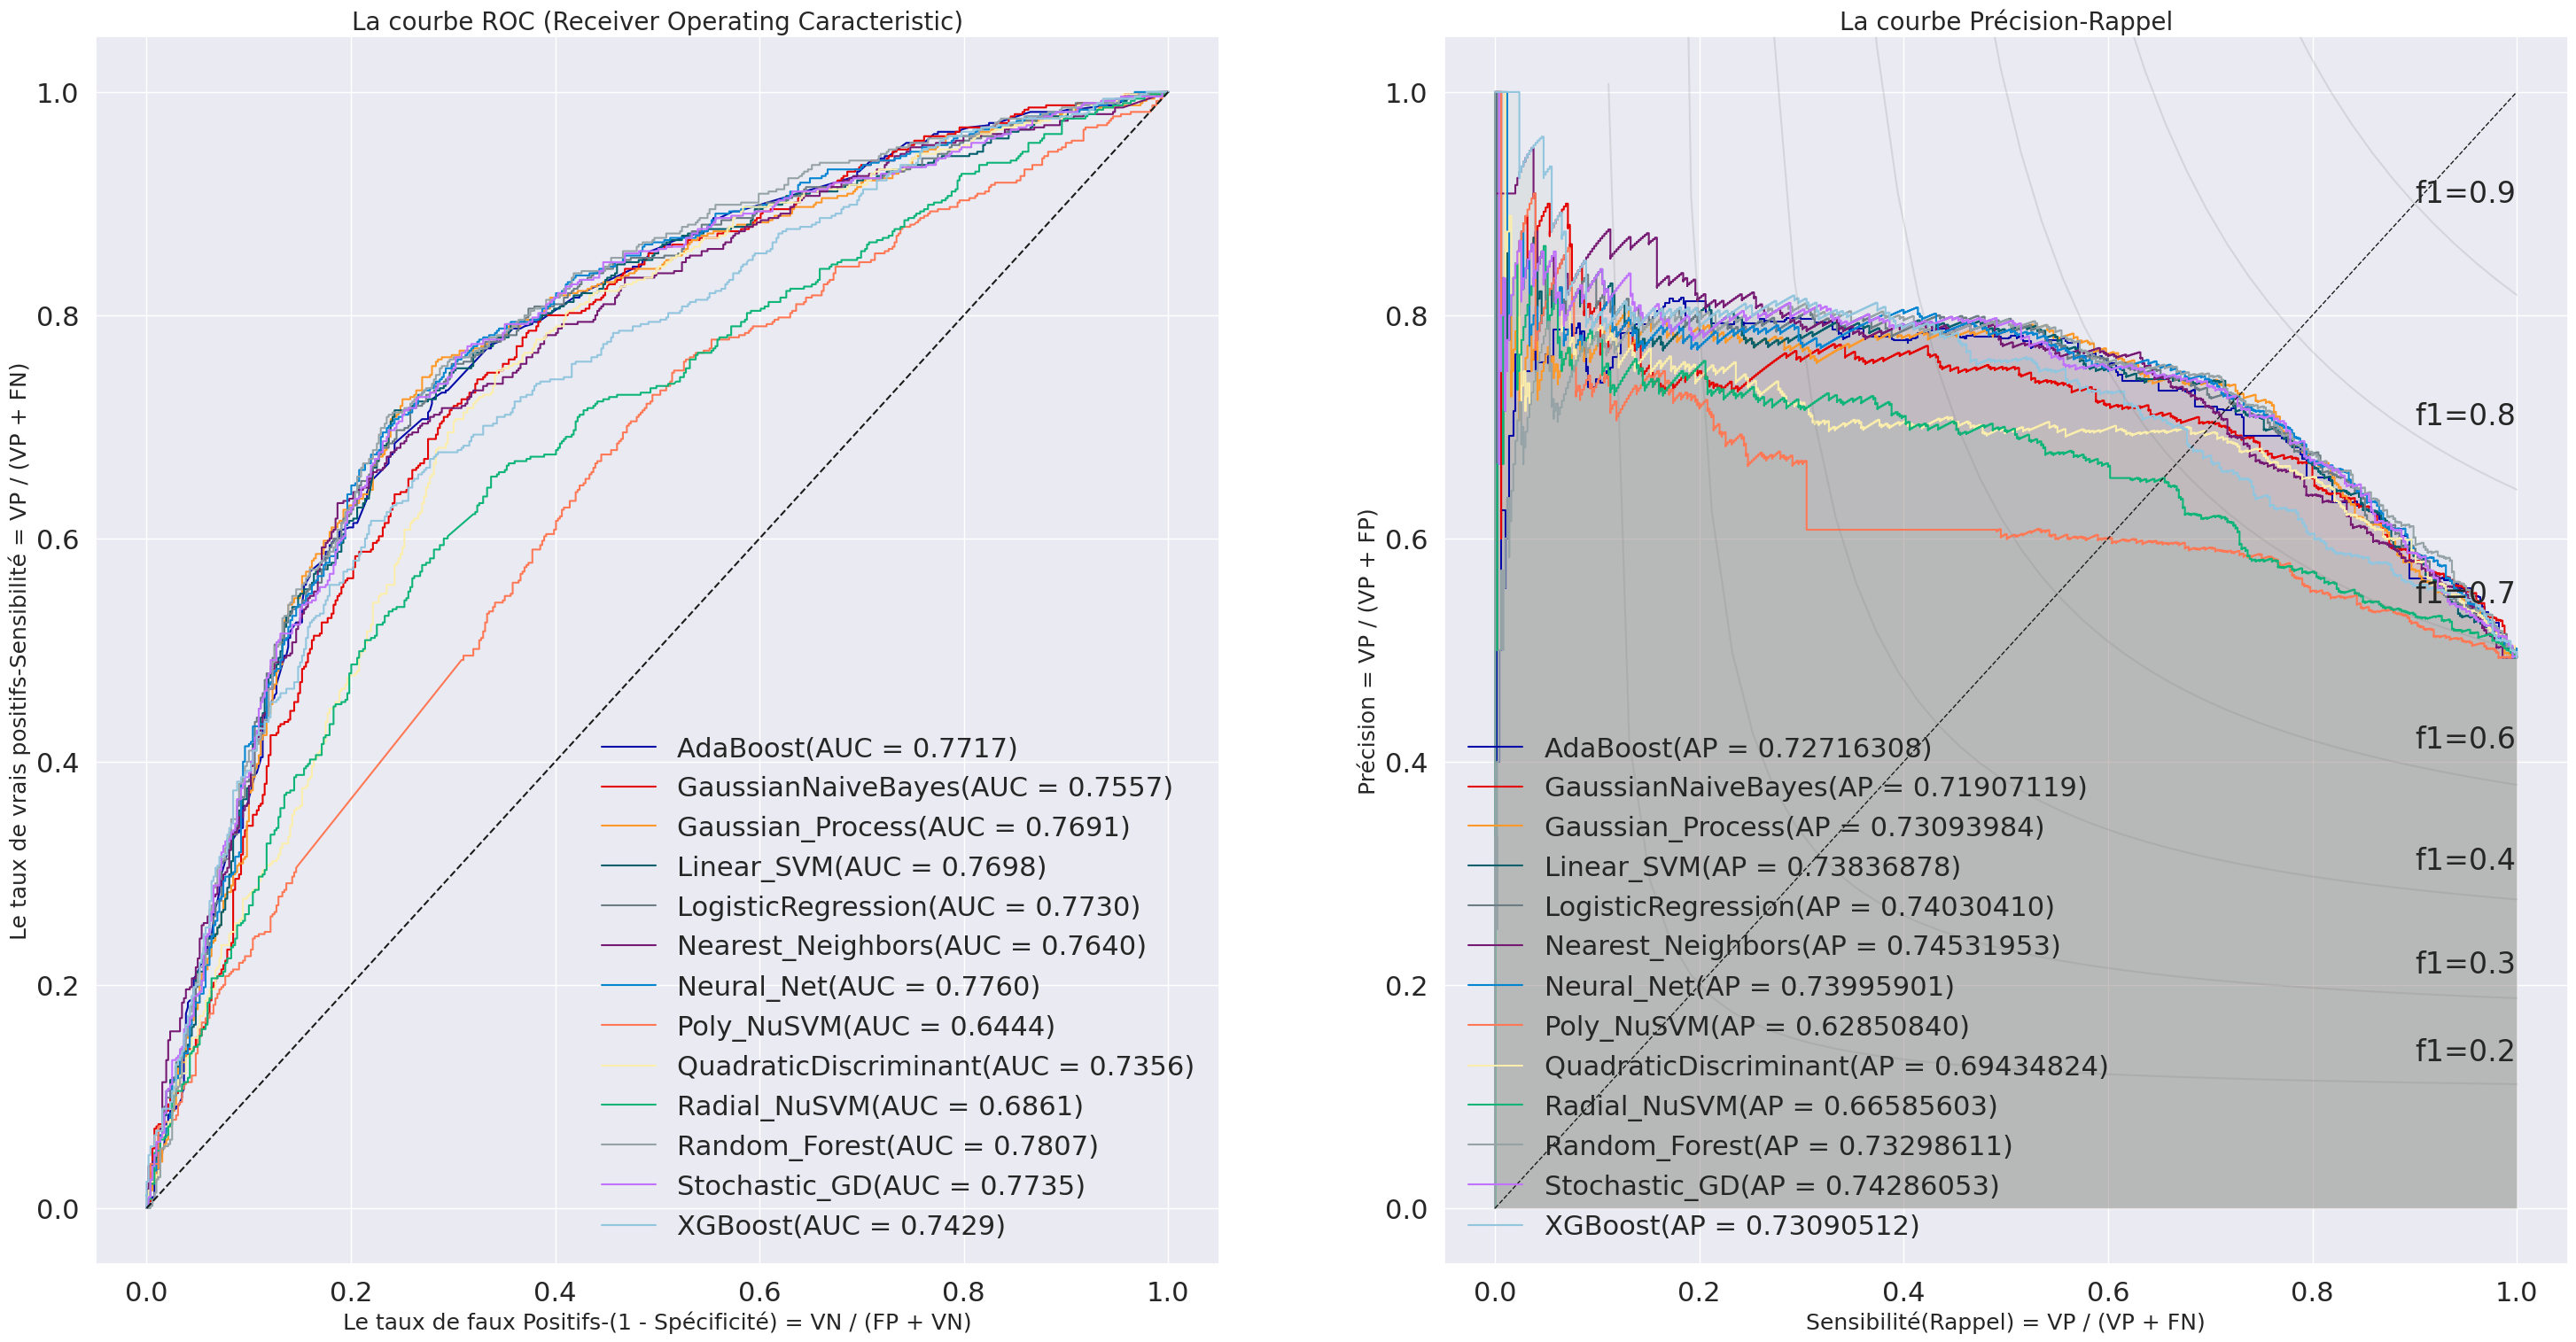

Exécution  :19.32s


In [27]:
resultatsTemp = executionEssaiComparaisonClassificateurs(classificateursDict, 
                                                     X_train, 
                                                     y_train,
                                                     X_test, 
                                                     y_test, 
                                                     couleurs = palette,
                                                     nom_essai = 'StandardScaler', 
                                                     projet=projet)

In [28]:
resultats = pd.concat([resultats,resultatsTemp])

In [29]:
resultats.drop(columns=['vrais_positifs', 'vrais_negatifs',
                         'faux_positifs', 'faux_negatifs']).sort_values('aucROC',ascending=False).head(25)

,aucROC,avgPrecRec,accuracy,f1,precision,sensibilite,specificite,logloss,hammingloss,jaccard,essai
Classifieur,,,,,,,,,,,
Random_Forest,0.780713,0.732986,0.728516,0.707983,0.753915,0.667327,0.788054,9.785289,0.271484,0.547967,StandardScaler
Random_Forest,0.780364,0.736097,0.725586,0.703273,0.753394,0.659406,0.789981,9.890885,0.274414,0.542345,Initial
Neural_Net,0.775999,0.739959,0.725586,0.708808,0.743478,0.677228,0.772640,9.890885,0.274414,0.548957,StandardScaler
Stochastic_GD,0.773523,0.742861,0.716797,0.692797,0.744875,0.647525,0.784200,10.207675,0.283203,0.529984,StandardScaler
LogisticRegression,0.773008,0.740313,0.719727,0.698212,0.744395,0.657426,0.780347,10.102079,0.280273,0.536349,Initial
LogisticRegression,0.773008,0.740304,0.719727,0.698212,0.744395,0.657426,0.780347,10.102079,0.280273,0.536349,StandardScaler
AdaBoost,0.771657,0.727163,0.712891,0.687234,0.742529,0.639604,0.784200,10.348471,0.287109,0.523501,StandardScaler
AdaBoost,0.771657,0.727163,0.712891,0.687234,0.742529,0.639604,0.784200,10.348471,0.287109,0.523501,Initial
Linear_SVM,0.769811,0.738369,0.705078,0.667401,0.751861,0.600000,0.807322,10.630062,0.294922,0.500826,StandardScaler


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Transformation des modalités en variables</div></b>

In [30]:
donneesXy = X.copy()
for colonne in ['GENDER','CHOLESTEROL','GLUCOSE']:
    createColumnsQualitatives(donneesXy,colonne)    

In [31]:
X_train, X_test = donneesXy.loc[('apprentissage'),:],donneesXy.loc[('test'),:]

AdaBoost               0.7129	--	Area under the ROC curve : 0.7717	--	Exécution  :.72s
GaussianNaiveBayes     0.6436	--	Area under the ROC curve : 0.7344	--	Exécution  :.01s
Gaussian_Process       0.6328	--	Area under the ROC curve : 0.6386	--	Exécution  :18.30s
Linear_SVM             0.7090	--	Area under the ROC curve : 0.7701	--	Exécution  :130.83s
LogisticRegression     0.7246	--	Area under the ROC curve : 0.7733	--	Exécution  :.72s
Nearest_Neighbors      0.6973	--	Area under the ROC curve : 0.7552	--	Exécution  :.18s
Neural_Net             0.6904	--	Area under the ROC curve : 0.7555	--	Exécution  :.23s
Poly_NuSVM             0.6973	--	Area under the ROC curve : 0.6006	--	Exécution  :.35s
QuadraticDiscriminant  0.5430	--	Area under the ROC curve : 0.5655	--	Exécution  :.01s
Radial_NuSVM           0.5801	--	Area under the ROC curve : 0.6398	--	Exécution  :3.33s
Random_Forest          0.7168	--	Area under the ROC curve : 0.7805	--	Exécution  :.49s
Stochastic_GD          0.5947	--	Area

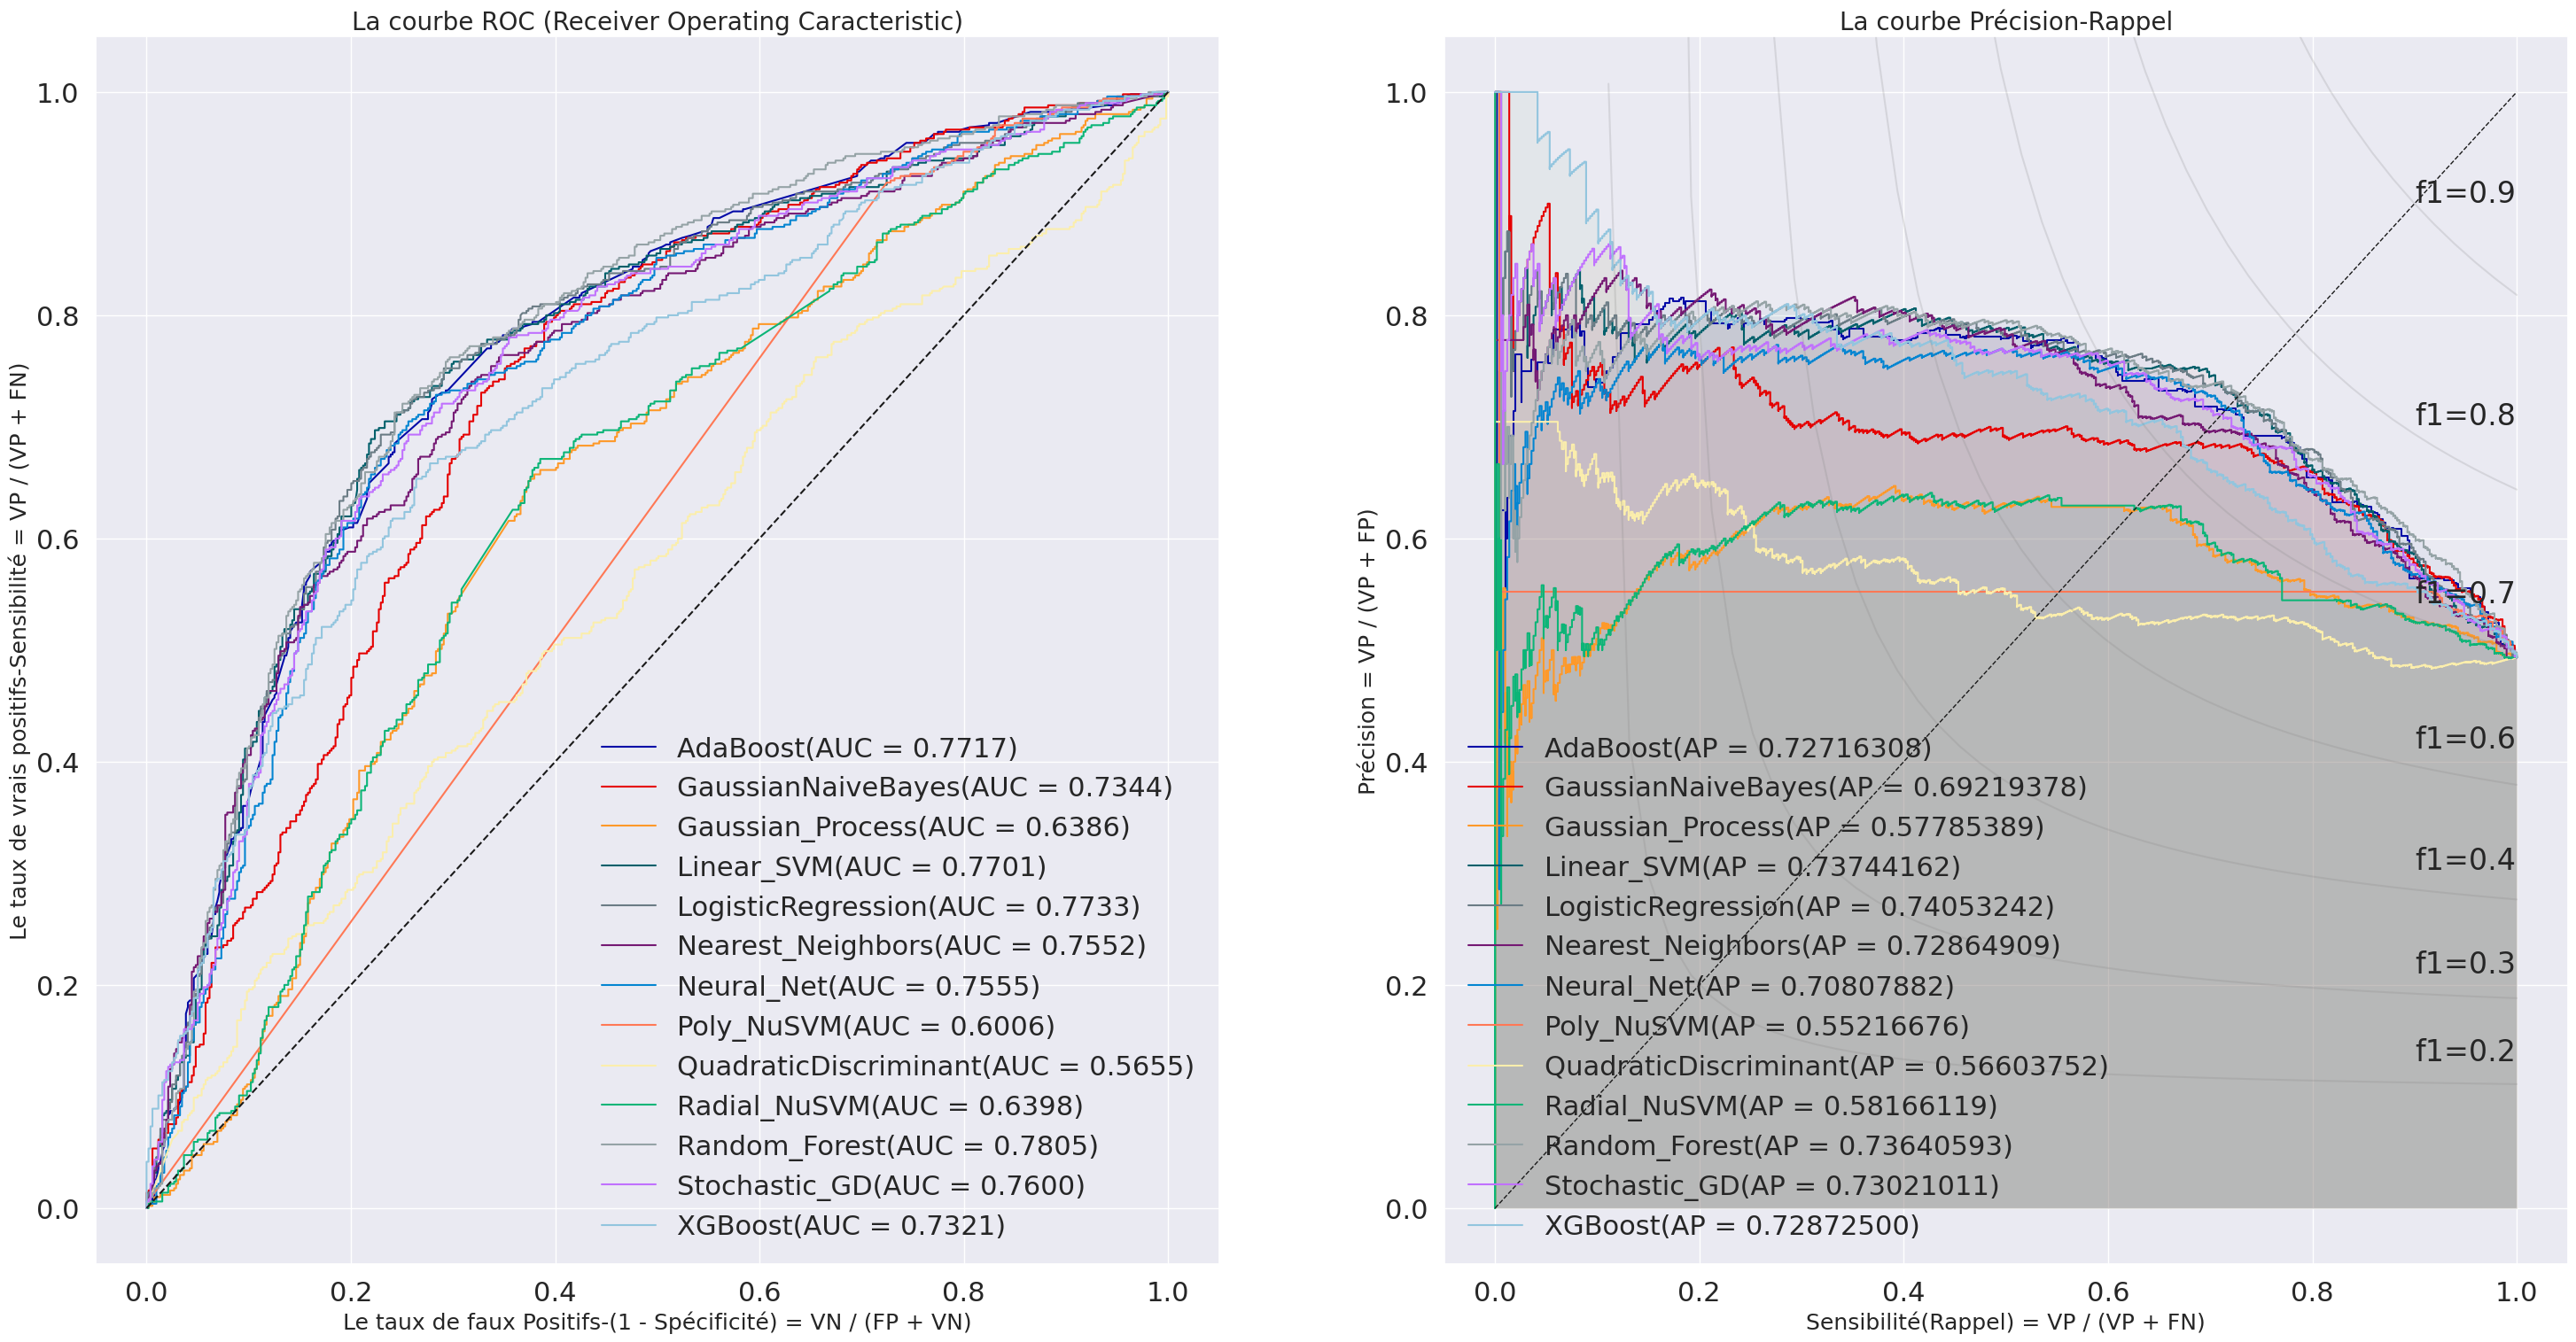

Exécution  :156.42s


In [32]:
resultatsTemp = executionEssaiComparaisonClassificateurs(classificateursDict, 
                                                     X_train, 
                                                     y_train,
                                                     X_test, 
                                                     y_test, 
                                                     couleurs = palette,
                                                     nom_essai = 'Modalites', 
                                                     projet=projet)
resultats = pd.concat([resultats,resultatsTemp])

In [33]:
resultats.drop(columns=['vrais_positifs', 'vrais_negatifs',
                         'faux_positifs', 'faux_negatifs']).sort_values('aucROC',ascending=False).head(25)

,aucROC,avgPrecRec,accuracy,f1,precision,sensibilite,specificite,logloss,hammingloss,jaccard,essai
Classifieur,,,,,,,,,,,
Random_Forest,0.780713,0.732986,0.728516,0.707983,0.753915,0.667327,0.788054,9.785289,0.271484,0.547967,StandardScaler
Random_Forest,0.780456,0.736406,0.716797,0.690832,0.748268,0.641584,0.789981,10.207675,0.283203,0.527687,Modalites
Random_Forest,0.780364,0.736097,0.725586,0.703273,0.753394,0.659406,0.789981,9.890885,0.274414,0.542345,Initial
Neural_Net,0.775999,0.739959,0.725586,0.708808,0.743478,0.677228,0.772640,9.890885,0.274414,0.548957,StandardScaler
Stochastic_GD,0.773523,0.742861,0.716797,0.692797,0.744875,0.647525,0.784200,10.207675,0.283203,0.529984,StandardScaler
LogisticRegression,0.773256,0.740532,0.724609,0.700000,0.756322,0.651485,0.795761,9.926084,0.275391,0.538462,Modalites
LogisticRegression,0.773008,0.740313,0.719727,0.698212,0.744395,0.657426,0.780347,10.102079,0.280273,0.536349,Initial
LogisticRegression,0.773008,0.740304,0.719727,0.698212,0.744395,0.657426,0.780347,10.102079,0.280273,0.536349,StandardScaler
AdaBoost,0.771657,0.727163,0.712891,0.687234,0.742529,0.639604,0.784200,10.348471,0.287109,0.523501,StandardScaler


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Affichage des évolutions des métriques dans les essais</div></b> 

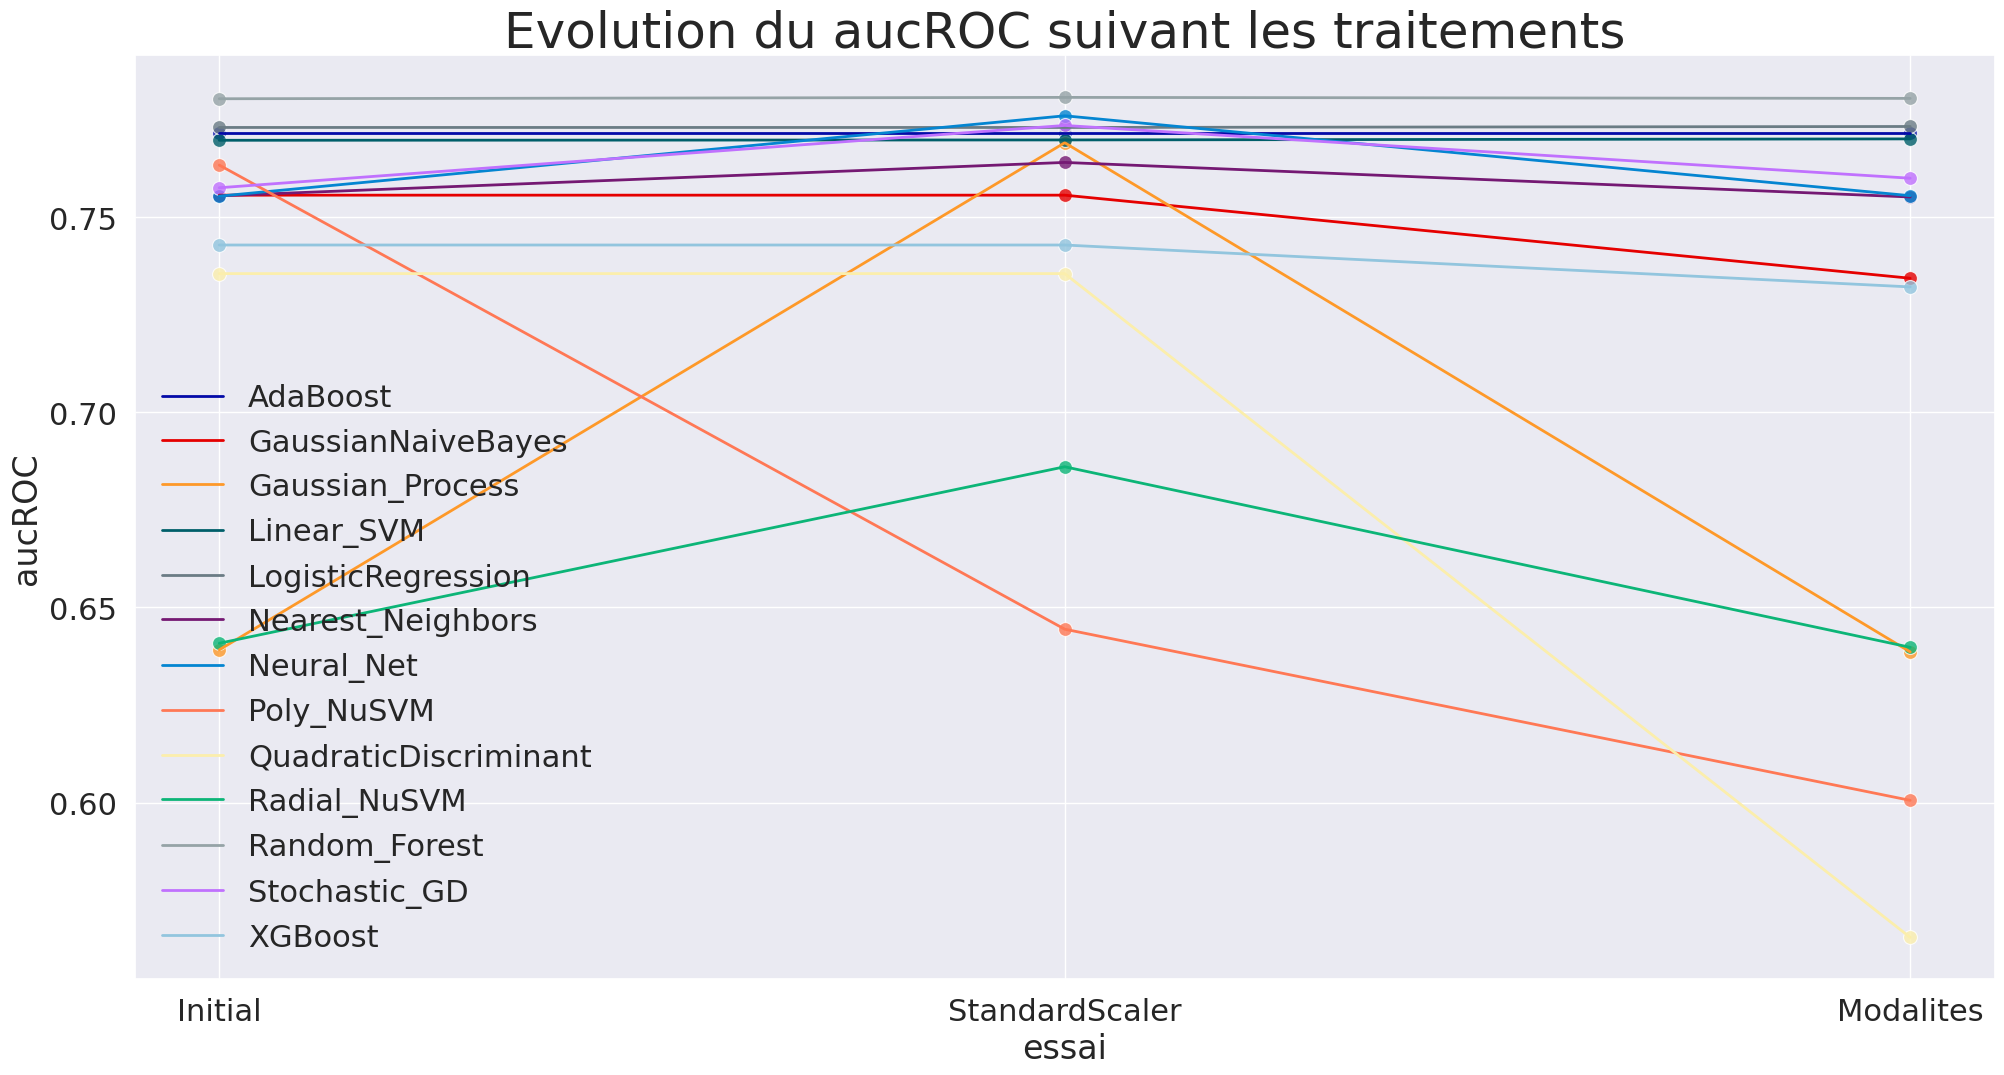

In [34]:
affichageEvolutionMetriques(resultats, metrique='aucROC', palette=palette)